# Requirements - installs and packages

In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from sklearn.mixture import GaussianMixture
from IPython.display import display, Math
from scipy.stats import multivariate_normal

# Function definitions

In [3]:
def load_simulations(counts_path, names_path, heatmap_path=None,
                     x_bins=None, y_bins=None):
    """
    Load simulation heat maps with labels.

    Returns
    -------
    sims : list of dict
        One dict per valid simulation with keys:
        'code', 'variant', 'heatmap', 'x_bins', 'y_bins'
    combined : np.ndarray
        The combined/averaged heat map from heatmap_path.
    """
    counts = np.load(counts_path)               # (N, 29, 29)
    names = np.load(names_path, allow_pickle=True)  # (144, 2)
    if heatmap_path is not None:
        combined = np.load(heatmap_path)
    else:
        combined = np.sum(counts, axis=0)

    if x_bins is None:
        x_bins = np.linspace(-4, -1, 30)
    if y_bins is None:
        y_bins = np.linspace(0.1, 1.4, 30)

    n_sims = counts.shape[0]
    sims = []
    for i in range(n_sims):
        sims.append({
            "index": i,
            "code": names[i, 0],
            "variant": names[i, 1],
            "heatmap": counts[i],
            "x_bins": x_bins,
            "y_bins": y_bins,
        })

    print(f"Loaded {n_sims} simulations from {len(names)} labels")
    return sims, combined


def plot_heatmaps(sims, indices=None, ncols=3, vmin=None, vmax=None):
    """
    Plot heat maps for selected simulations.

    Parameters
    ----------
    sims : list of dict
        Output from load_simulations.
    indices : int, list of int, or None
        Which sims to plot (by position in sims list).
        None plots all. A single int plots one.
    ncols : int
        Max columns in the grid.
    vmin, vmax : float or None
        Color scale limits. If None, auto-scaled across all
        selected heat maps (ignoring zeros).
    """
    # Normalize indices
    if indices is None:
        indices = list(range(len(sims)))
    elif isinstance(indices, int):
        indices = [indices]

    n = len(indices)
    ncols = min(ncols, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5 * ncols, 4 * nrows),
                             squeeze=False, constrained_layout=True)

    # Auto-detect color range if not provided
    if vmin is None or vmax is None:
        all_vals = np.concatenate([sims[i]["heatmap"].ravel() for i in indices])
        positive = all_vals[all_vals > 0]
        if len(positive) > 0:
            vmin = vmin or positive.min()
            vmax = vmax or positive.max()
        else:
            vmin, vmax = 1e-3, 1

    for ax_idx, sim_idx in enumerate(indices):
        row, col = divmod(ax_idx, ncols)
        ax = axes[row][col]
        sim = sims[sim_idx]

        safe = np.where(sim["heatmap"] > 0, sim["heatmap"], np.nan)
        im = ax.pcolormesh(sim["x_bins"], sim["y_bins"], safe,
                           shading="auto", cmap="viridis",
                           norm=LogNorm(vmin=vmin, vmax=vmax))
        ax.set_xlabel("log10(frequency/Hz)")
        ax.set_ylabel("chirp mass [Msun]")
        ax.set_title(f"{sim['code']} | {sim['variant']}", fontsize=10)

    # Turn off unused axes
    for ax_idx in range(n, nrows * ncols):
        row, col = divmod(ax_idx, ncols)
        axes[row][col].axis("off")

    fig.colorbar(im, ax=axes, label="normalized counts per bin",
                 shrink=0.8)
    plt.show()



In [4]:
def _heatmap_to_samples(heatmap, x_bins, y_bins, n_samples=10000):
    """Convert a 2D histogram into weighted point samples."""
    x_centers = 0.5 * (x_bins[:-1] + x_bins[1:])
    y_centers = 0.5 * (y_bins[:-1] + y_bins[1:])
    xx, yy = np.meshgrid(x_centers, y_centers)

    coords = np.column_stack([xx.ravel(), yy.ravel()])  # (841, 2)
    weights = heatmap.ravel()

    # Keep only positive bins
    mask = weights > 0
    coords = coords[mask]
    weights = weights[mask]

    # Resample proportional to weights
    probs = weights / weights.sum()
    indices = np.random.choice(len(coords), size=n_samples, p=probs)
    return coords[indices]


def _evaluate_gmm_on_grid(gmm, x_bins, y_bins):
    """Evaluate a fitted GMM on the bin grid, returning (29,29) array."""
    x_centers = 0.5 * (x_bins[:-1] + x_bins[1:])
    y_centers = 0.5 * (y_bins[:-1] + y_bins[1:])
    xx, yy = np.meshgrid(x_centers, y_centers)
    grid_pts = np.column_stack([xx.ravel(), yy.ravel()])

    log_density = gmm.score_samples(grid_pts)  # log-probability
    density = np.exp(log_density).reshape(xx.shape)
    return density


def fit_gmm(sim, max_components=6, n_samples=10000, random_state=42):
    """
    Fit a GMM to a single simulation's heatmap.
    Selects number of components via BIC.

    Parameters
    ----------
    sim : dict from load_simulations
    max_components : int
        Try 1..max_components and pick best BIC.
    n_samples : int
        Synthetic samples to draw from heatmap.

    Returns
    -------
    result : dict with keys:
        'gmm'        : fitted GaussianMixture object
        'n_components': chosen number
        'bic'        : BIC of chosen model
        'all_bics'   : list of (n, bic) for all tried
        'r_squared'  : R² between original and reconstructed heatmap
        'residuals'  : original - reconstructed (29,29)
        'reconstructed': the GMM-predicted heatmap (29,29)
        'code', 'variant': labels
    """
    heatmap = sim["heatmap"]
    x_bins, y_bins = sim["x_bins"], sim["y_bins"]
    total_counts = heatmap.sum()

    # Skip nearly empty maps
    if total_counts < 1e-10:
        return None

    np.random.seed(random_state)
    samples = _heatmap_to_samples(heatmap, x_bins, y_bins,
                                  n_samples=n_samples)

    # Try different component counts, pick best BIC
    bics = []
    gmms = []
    for n in range(1, max_components + 1):
        gmm = GaussianMixture(n_components=n, covariance_type="full",
                              random_state=random_state, max_iter=300)
        gmm.fit(samples)
        bics.append((n, gmm.bic(samples)))
        gmms.append(gmm)

    best_idx = np.argmin([b[1] for b in bics])
    best_gmm = gmms[best_idx]
    best_n = bics[best_idx][0]

    # Reconstruct heatmap from GMM
    density = _evaluate_gmm_on_grid(best_gmm, x_bins, y_bins)
    # Scale density to match original total counts
    dx = x_bins[1] - x_bins[0]
    dy = y_bins[1] - y_bins[0]
    reconstructed = density * total_counts * dx * dy

    # R² on non-zero bins
    mask = heatmap > 0
    if mask.sum() > 0:
        ss_res = np.sum((heatmap[mask] - reconstructed[mask]) ** 2)
        ss_tot = np.sum((heatmap[mask] - heatmap[mask].mean()) ** 2)
        r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    else:
        r_squared = 0.0

    return {
        "gmm": best_gmm,
        "n_components": best_n,
        "bic": bics[best_idx][1],
        "all_bics": bics,
        "r_squared": r_squared,
        "residuals": heatmap - reconstructed,
        "reconstructed": reconstructed,
        "code": sim.get("code", ""),
        "variant": sim.get("variant", ""),
        "total_counts": total_counts,
    }


def sum_gmm_fits(fit_results, x_bins=None, y_bins=None):
    """
    Combine individual GMM fits into a single predicted heatmap
    by summing each simulation's reconstructed map.

    Parameters
    ----------
    fit_results : list of dicts from fit_gmm
    x_bins, y_bins : arrays (uses first result's bins if None)

    Returns
    -------
    dict with keys:
        'reconstructed' : (29,29) summed prediction
        'gmms'          : list of (gmm, weight) pairs for the combined mixture
        'n_total_components' : total components across all fits
    """
    if x_bins is None:
        x_bins = np.linspace(-4, -1, 30)
    if y_bins is None:
        y_bins = np.linspace(0.1, 1.4, 30)

    valid = [r for r in fit_results if r is not None]
    summed = np.zeros((len(y_bins) - 1, len(x_bins) - 1))

    combined_means = []
    combined_covs = []
    combined_weights = []
    total_weight = sum(r["total_counts"] for r in valid)

    for r in valid:
        summed += r["reconstructed"]

        # Build combined mixture: scale each GMM's weights by its
        # fraction of total counts
        gmm = r["gmm"]
        scale = r["total_counts"] / total_weight
        for k in range(gmm.n_components):
            combined_means.append(gmm.means_[k])
            combined_covs.append(gmm.covariances_[k])
            combined_weights.append(gmm.weights_[k] * scale)

    combined_weights = np.array(combined_weights)
    combined_weights /= combined_weights.sum()  # renormalize

    return {
        "reconstructed": summed,
        "combined_means": np.array(combined_means),
        "combined_covariances": np.array(combined_covs),
        "combined_weights": combined_weights,
        "n_total_components": len(combined_weights),
        "n_sims": len(valid),
    }


def fit_gmm_total(combined_heatmap, x_bins=None, y_bins=None,
                  max_components=8, n_samples=20000, random_state=42):
    """
    Fit a GMM directly to the combined/total heatmap.

    Parameters
    ----------
    combined_heatmap : (29,29) array
    max_components : int
    n_samples : int

    Returns
    -------
    Same dict structure as fit_gmm, with code='COMBINED'.
    """
    if x_bins is None:
        x_bins = np.linspace(-4, -1, 30)
    if y_bins is None:
        y_bins = np.linspace(0.1, 1.4, 30)

    sim = {
        "heatmap": combined_heatmap,
        "x_bins": x_bins,
        "y_bins": y_bins,
    }

    result = fit_gmm(sim, max_components=max_components,
                     n_samples=n_samples, random_state=random_state)
    if result is not None:
        result["code"] = "COMBINED"
        result["variant"] = "total"
    return result

In [5]:
def plot_gmm_comparison(heatmap, result, x_bins=None, y_bins=None, title=""):
    """
    Plot original heatmap with GMM contours overlaid, plus residuals.
    """
    if x_bins is None:
        x_bins = np.linspace(-4, -1, 30)
    if y_bins is None:
        y_bins = np.linspace(0.1, 1.4, 30)

    recon = result["reconstructed"]
    safe_orig = np.where(heatmap > 0, heatmap, np.nan)
    residuals = heatmap - recon

    # Fine grid for smooth GMM contours
    x_fine = np.linspace(x_bins[0], x_bins[-1], 200)
    y_fine = np.linspace(y_bins[0], y_bins[-1], 200)
    xx, yy = np.meshgrid(x_fine, y_fine)

    if "gmm" in result:
        grid_pts = np.column_stack([xx.ravel(), yy.ravel()])
        density = np.exp(result["gmm"].score_samples(grid_pts)).reshape(xx.shape)
    else:
        from scipy.stats import multivariate_normal
        grid_pts = np.column_stack([xx.ravel(), yy.ravel()])
        density = np.zeros(len(grid_pts))
        for mu, cov, w in zip(result["combined_means"],
                              result["combined_covariances"],
                              result["combined_weights"]):
            density += w * multivariate_normal.pdf(grid_pts, mean=mu, cov=cov)
        density = density.reshape(xx.shape)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    # Original heatmap + GMM contours
    im0 = axes[0].pcolormesh(x_bins, y_bins, safe_orig, shading="auto",
                             cmap="viridis", norm=LogNorm())
    #axes[0].contour(xx, yy, density, levels=8, colors="white", linewidths=0.8, alpha=0.9)

    pcts = [1, 5, 10, 20, 30, 50, 65, 70, 75, 80, 85, 90, 95, 96, 97, 98, 99]
    levels = np.percentile(density[density > 0], pcts)
    levels = np.unique(levels)
    axes[0].contour(xx, yy, density, levels=levels, colors="white",
                    linewidths=0.6, alpha=0.9)
    
    axes[0].set_title(f"{title} Data + GMM contours")
    axes[0].set_xlabel("log10(frequency/Hz)")
    axes[0].set_ylabel("chirp mass [Msun]")
    plt.colorbar(im0, ax=axes[0])

    # Residuals
    res_max = np.nanmax(np.abs(residuals))
    im1 = axes[1].pcolormesh(x_bins, y_bins, residuals, shading="auto",
                             cmap="RdBu_r", vmin=-res_max, vmax=res_max)
    axes[1].set_title(f"{title} Residuals")
    axes[1].set_xlabel("log10(frequency/Hz)")
    axes[1].set_ylabel("chirp mass [Msun]")
    plt.colorbar(im1, ax=axes[1])

    # R²
    if "r_squared" in result:
        r2 = result["r_squared"]
    else:
        mask = heatmap > 0
        ss_res = np.sum((heatmap[mask] - recon[mask]) ** 2)
        ss_tot = np.sum((heatmap[mask] - heatmap[mask].mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    fig.suptitle(f"R² = {r2:.4f}", y=0.02, fontsize=12)

    plt.show()

In [6]:
def print_gmm_params(result):
    """Print GMM fit parameters from a fit_gmm / fit_gmm_total result."""
    gmm = result["gmm"]
    print(f"R²:         {result['r_squared']:.4f}")
    print(f"Components: {result['n_components']}")
    print(f"BIC:        {result['bic']:.2f}")
    print()
    for k in range(gmm.n_components):
        print(f"Component {k+1}:  weight = {gmm.weights_[k]:.4f}")
        print(f"  μ  = [freq: {gmm.means_[k][0]:.4f}, Mc: {gmm.means_[k][1]:.4f}]")
        print(f"  Σ  = [[{gmm.covariances_[k][0,0]:.6f}, {gmm.covariances_[k][0,1]:.6f}],")
        print(f"        [{gmm.covariances_[k][1,0]:.6f}, {gmm.covariances_[k][1,1]:.6f}]]")
    print()
    print("p(f, Mc) = Σ_k  w_k · N([f, Mc] | μ_k, Σ_k)")

In [7]:
def GMM_combined_fit(total_fit, printLaTeX=False):
    """Extract fit function from total_fit, print params and LaTeX."""
    from scipy.stats import multivariate_normal

    gmm = total_fit["gmm"]
    weights = gmm.weights_.tolist()
    means = gmm.means_.tolist()
    covs = gmm.covariances_.tolist()
    n = gmm.n_components

    # Print parameters
    #print(f"R²:         {total_fit['r_squared']:.4f}")
    #print(f"Components: {n}")
    #print(f"BIC:        {total_fit['bic']:.2f}")
    #print()
    #for k in range(n):
    #    print(f"Component {k+1}:  weight = {weights[k]:.4f}")
    #    print(f"  μ  = [freq: {means[k][0]:.4f}, Mc: {means[k][1]:.4f}]")
    #    print(f"  Σ  = [[{covs[k][0][0]:.6f}, {covs[k][0][1]:.6f}],")
    #    print(f"        [{covs[k][1][0]:.6f}, {covs[k][1][1]:.6f}]]")
    #print()

    # Rendered LaTeX
    display(Math(
        r"p(f, \mathcal{M}_c) = \sum_{k=1}^{" + str(n) + r"} w_k \, "
        r"\mathcal{N}\!\left(\begin{bmatrix} f \\ \mathcal{M}_c "
        r"\end{bmatrix} \bigg| \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k\right)"
    ))
    for k in range(n):
        display(Math(
            f"k={k+1}: \\quad w_{{{k+1}}} = {weights[k]:.4f}, \\quad "
            f"\\boldsymbol{{\\mu}}_{{{k+1}}} = \\begin{{bmatrix}} {means[k][0]:.4f} \\\\ {means[k][1]:.4f} \\end{{bmatrix}}, \\quad "
            f"\\boldsymbol{{\\Sigma}}_{{{k+1}}} = \\begin{{bmatrix}} {covs[k][0][0]:.6f} & {covs[k][0][1]:.6f} \\\\ {covs[k][1][0]:.6f} & {covs[k][1][1]:.6f} \\end{{bmatrix}}"
        ))
        
    # LaTeX
    if printLaTeX:
        print(r"$p(f, \mathcal{M}_c) = \sum_{k=1}^{" + str(n) + r"} w_k \, "
              r"\mathcal{N}\!\left(\begin{bmatrix} f \\ \mathcal{M}_c "
              r"\end{bmatrix} \bigg| \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k\right)$")
        print()
        for k in range(n):
            print(f"$k={k+1}: \\quad w_{{{k+1}}} = {weights[k]:.4f}, \\quad "
                  f"\\boldsymbol{{\\mu}}_{{{k+1}}} = \\begin{{bmatrix}} {means[k][0]:.4f} \\\\ {means[k][1]:.4f} \\end{{bmatrix}}, \\quad "
                  f"\\boldsymbol{{\\Sigma}}_{{{k+1}}} = \\begin{{bmatrix}} {covs[k][0][0]:.6f} & {covs[k][0][1]:.6f} \\\\ {covs[k][1][0]:.6f} & {covs[k][1][1]:.6f} \\end{{bmatrix}}$")
    
    # Return callable fit function
    def fit_func(f, Mc):
        pt = np.atleast_2d(np.column_stack([np.ravel(f), np.ravel(Mc)]))
        result = np.zeros(len(pt))
        for w, mu, cov in zip(weights, means, covs):
            result += w * multivariate_normal.pdf(pt, mean=mu, cov=cov)
        return result.reshape(np.shape(f))

    return fit_func

In [8]:
def prior_sanity_check(fit_func, data, x_bins=None, y_bins=None):
    """Plot fit vs data side by side and compute R²."""
    if x_bins is None:
        x_bins = np.linspace(-4, -1, 30)
    if y_bins is None:
        y_bins = np.linspace(0.1, 1.4, 30)

    # Fine grid for smooth GMM
    f = np.linspace(x_bins[0], x_bins[-1], 200)
    Mc = np.linspace(y_bins[0], y_bins[-1], 200)
    ff, mm = np.meshgrid(f, Mc)
    density = fit_func(ff, mm)

    safe = np.where(data > 0, data, np.nan)
    dx = x_bins[1] - x_bins[0]
    dy = y_bins[1] - y_bins[0]
    density_scaled = density * data.sum() * dx * dy

    # Color limits from data
    pos_data = data[data > 0]
    norm = LogNorm(vmin=pos_data.min(), vmax=pos_data.max())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

    # Left: data + contours
    im0 = axes[0].pcolormesh(x_bins, y_bins, safe, shading="auto",
                             cmap="viridis", norm=norm)
    pcts = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 85, 90, 95, 97, 99]
    levels = np.unique(np.percentile(density[density > 0], pcts))
    axes[0].contour(ff, mm, density, levels=levels, colors="white",
                    linewidths=0.7, alpha=0.9)
    axes[0].set_xlabel("log10(frequency/Hz)")
    axes[0].set_ylabel("chirp mass [Msun]")
    axes[0].set_title("Data + GMM contours")

    # Right: GMM fit heatmap
    im1 = axes[1].pcolormesh(ff, mm, density_scaled, shading="auto",
                             cmap="viridis", norm=norm)
    axes[1].contour(ff, mm, density, levels=levels, colors="white",
                    linewidths=0.7, alpha=0.9)
    axes[1].set_xlabel("log10(frequency/Hz)")
    axes[1].set_ylabel("chirp mass [Msun]")
    axes[1].set_title("GMM fit")
    axes[1].set_xlim(x_bins[0], x_bins[-1])
    axes[1].set_ylim(y_bins[0], y_bins[-1])

    fig.colorbar(im0, ax=axes, label="normalized counts per bin", shrink=0.8)
    plt.show()

    # R²
    x_centers = 0.5 * (x_bins[:-1] + x_bins[1:])
    y_centers = 0.5 * (y_bins[:-1] + y_bins[1:])
    xc, yc = np.meshgrid(x_centers, y_centers)
    fit_on_grid = fit_func(xc, yc) * data.sum() * dx * dy

    mask = data > 0
    ss_res = np.sum((data[mask] - fit_on_grid[mask]) ** 2)
    ss_tot = np.sum((data[mask] - data[mask].mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    print(f"R² = {r2:.4f}")
    return r2

# Total heatmap

Shape: (29, 29)
Min: 0.0000  Max: 527.5378


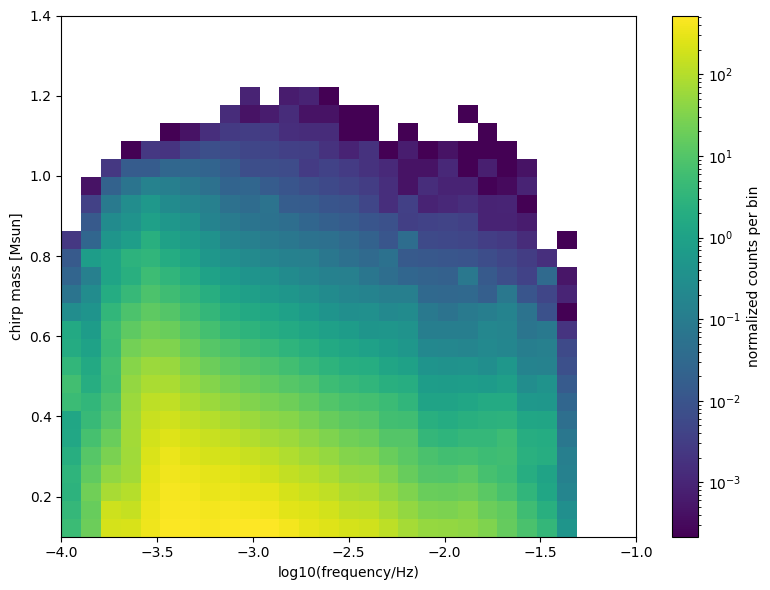

In [9]:
# Load data
heat_map = np.load("heat_map.npy")

x_bins = np.linspace(-4, -1, 30)   # log10(frequency/Hz)
y_bins = np.linspace(0.1, 1.4, 30) # chirp mass [Msun]

print(f"Shape: {heat_map.shape}")
print(f"Min: {heat_map.min():.4f}  Max: {heat_map.max():.4f}")

fig, ax = plt.subplots(figsize=(8, 6))

# Mask zeros/negatives so LogNorm doesn't choke
safe = np.where(heat_map > 0, heat_map, np.nan)

im = ax.pcolormesh(x_bins, y_bins, safe, shading="auto",
                   cmap="viridis", norm=LogNorm())
ax.set_xlabel("log10(frequency/Hz)")
ax.set_ylabel("chirp mass [Msun]")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("normalized counts per bin")

plt.tight_layout()
plt.savefig("heatmap_log.png", dpi=150)
plt.show()

# Individual model heatmaps and Total heatmap with SNR cut

Loaded 102 simulations from 102 labels


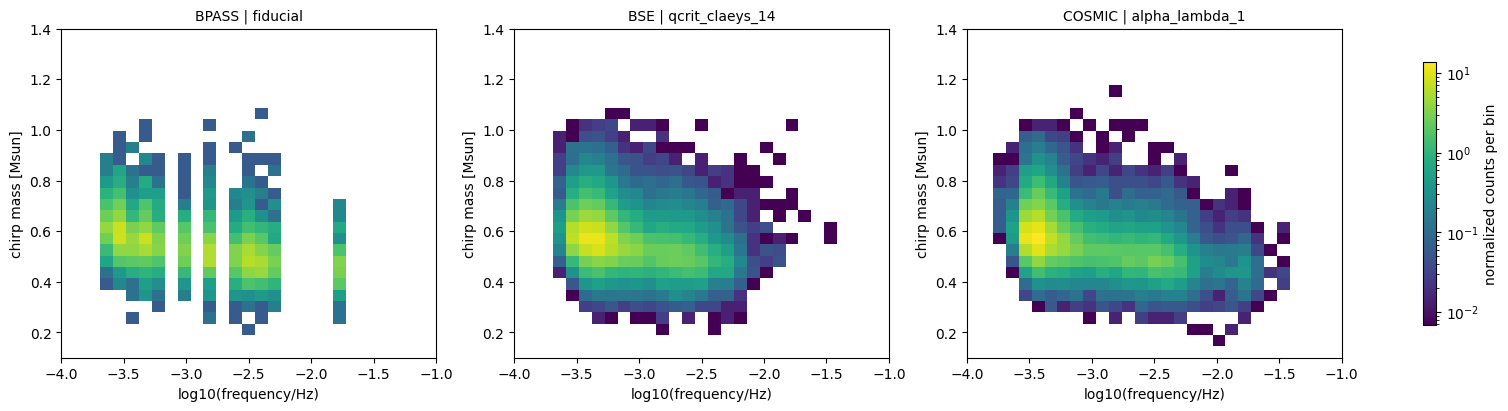

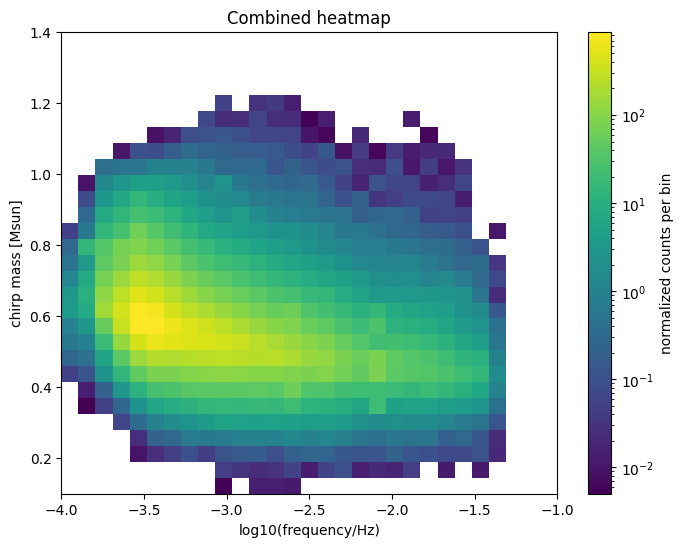

In [10]:
sims, combined = load_simulations("counts_list_snr_1.npy", "file_pair_names_1.npy")

# Plot a few examples
plot_heatmaps(sims, indices=[0, 18, 54])

# Plot combined separately
fig, ax = plt.subplots(figsize=(8, 6))
safe = np.where(combined > 0, combined, np.nan)
im = ax.pcolormesh(sims[0]["x_bins"], sims[0]["y_bins"], safe,
                   shading="auto", cmap="viridis", norm=LogNorm())
ax.set_xlabel("log10(frequency/Hz)")
ax.set_ylabel("chirp mass [Msun]")
ax.set_title("Combined heatmap")
plt.colorbar(im, ax=ax, label="normalized counts per bin")
plt.show()

# Fitting GMMs to Individual heatmaps and Total heatmap

In [11]:
sims, combined = load_simulations(
    "counts_list_snr_1.npy", "file_pair_names_1.npy")

# 1) Fit one simulation
r = fit_gmm(sims[18])  # BSE fiducial
print(f"\n--- {r['code']} | {r['variant']} ---")
print(f"  Components: {r['n_components']}")
print(f"  R²: {r['r_squared']:.4f}")
print(f"  BICs: {r['all_bics']}")

# 2) Fit all, sum GMMs
print("\nFitting all simulations...")
all_fits = [fit_gmm(s) for s in sims]
for r in sorted(all_fits, key=lambda x: -x["r_squared"]):
    print(f"  {r['code']:>10s} | {r['variant']:<22s}  n={r['n_components']}  R²={r['r_squared']:.3f}")

valid = [r for r in all_fits if r is not None]
print(f"  Valid fits: {len(valid)}")

summed = sum_gmm_fits(all_fits)
print(f"\n  Summed GMM: {summed['n_total_components']} total components "
      f"from {summed['n_sims']} sims")

# 3) Sum only good fits (R² > 0.5)
good_fits = [r for r in all_fits if r is not None and r["r_squared"] > 0.5]
print(f"\n  Fits with R² > 0.5: {len(good_fits)} / {len(all_fits)}")
summed_select = sum_gmm_fits(good_fits)
print(f"  Selected GMM: {summed_select['n_total_components']} components "
      f"from {summed_select['n_sims']} sims")

# 4) Fit GMM directly to total
total_fit = fit_gmm_total(combined)
print(f"\n--- Direct fit to combined ---")
print(f"  Components: {total_fit['n_components']}")
print(f"  R²: {total_fit['r_squared']:.4f}")

Loaded 102 simulations from 102 labels

--- BSE | qcrit_claeys_14 ---
  Components: 5
  R²: 0.9827
  BICs: [(1, -13588.98236766397), (2, -17809.515296643527), (3, -17827.509950472584), (4, -18907.30506736049), (5, -18960.22609007335), (6, -18704.039064146513)]

Fitting all simulations...
      COSMIC | alpha_lambda_05         n=6  R²=0.989
        SEVN | accretion_1             n=5  R²=0.988
      COSMIC | qcrit_hurley_webbink    n=6  R²=0.987
        SEVN | alpha_lambda_1          n=6  R²=0.986
      COSMIC | m2_min_05               n=6  R²=0.985
        SEVN | qcrit_claeys_14         n=5  R²=0.985
        SEVN | fiducial                n=5  R²=0.985
        SEVN | qcrit_hurley_02         n=5  R²=0.984
        SEVN | thermal_ecc             n=6  R²=0.983
        SEVN | porb_log_uniform        n=5  R²=0.983
         BSE | qcrit_claeys_14         n=5  R²=0.983
        SEVN | alpha_lambda_2          n=4  R²=0.983
      COMPAS | qmin_01                 n=6  R²=0.982
      COMPAS | fiducia

# Plotting the GMM fits

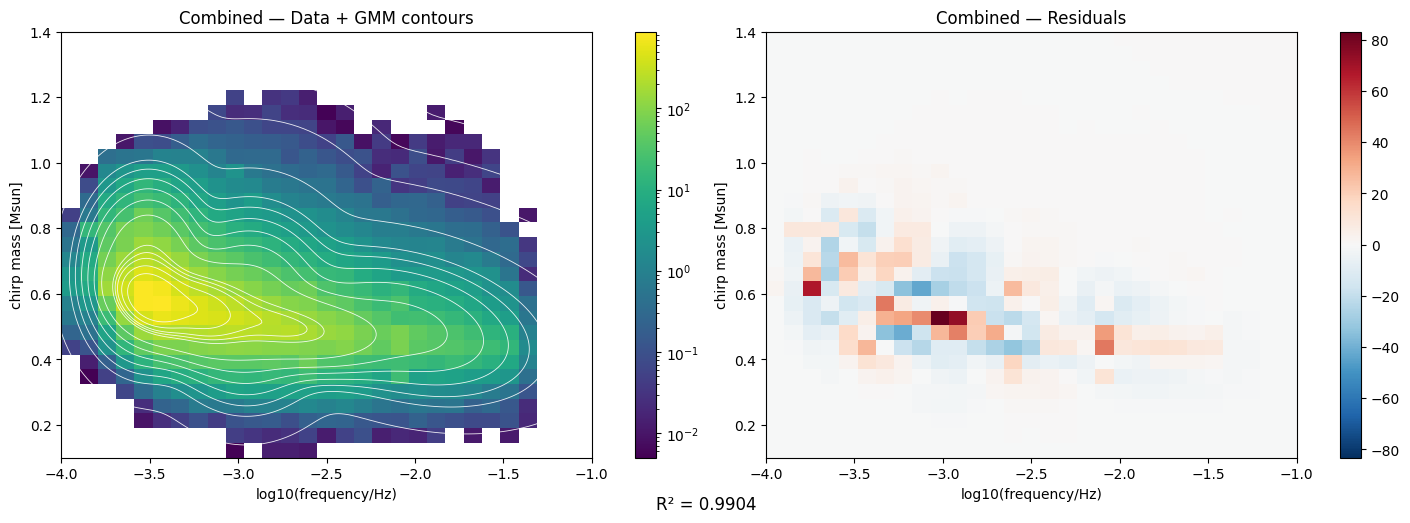

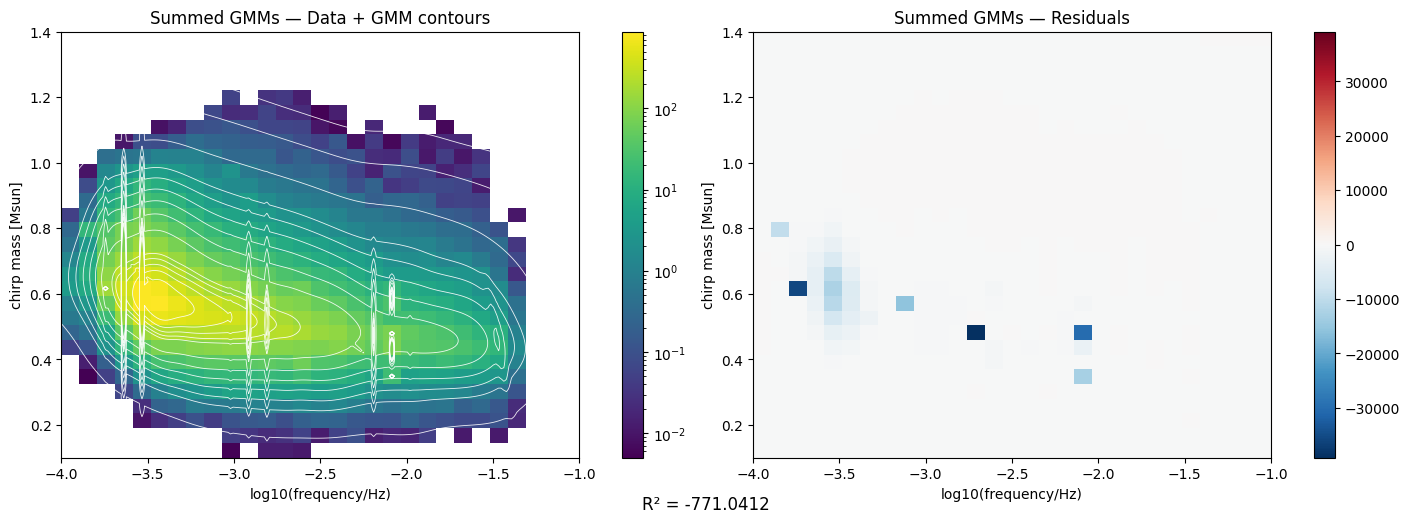

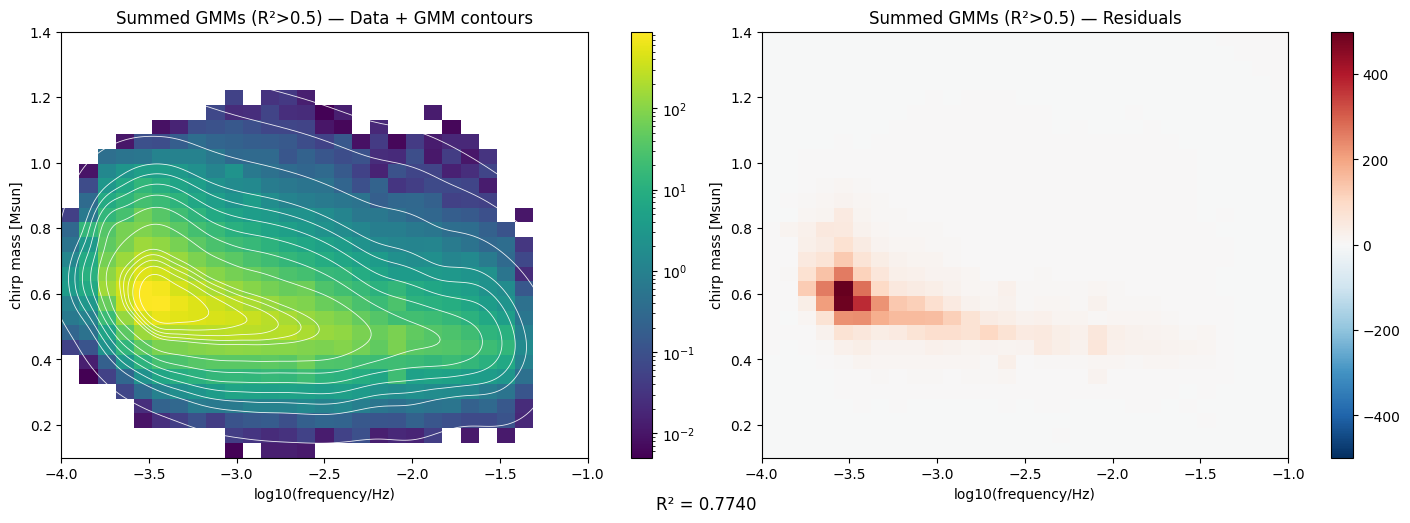

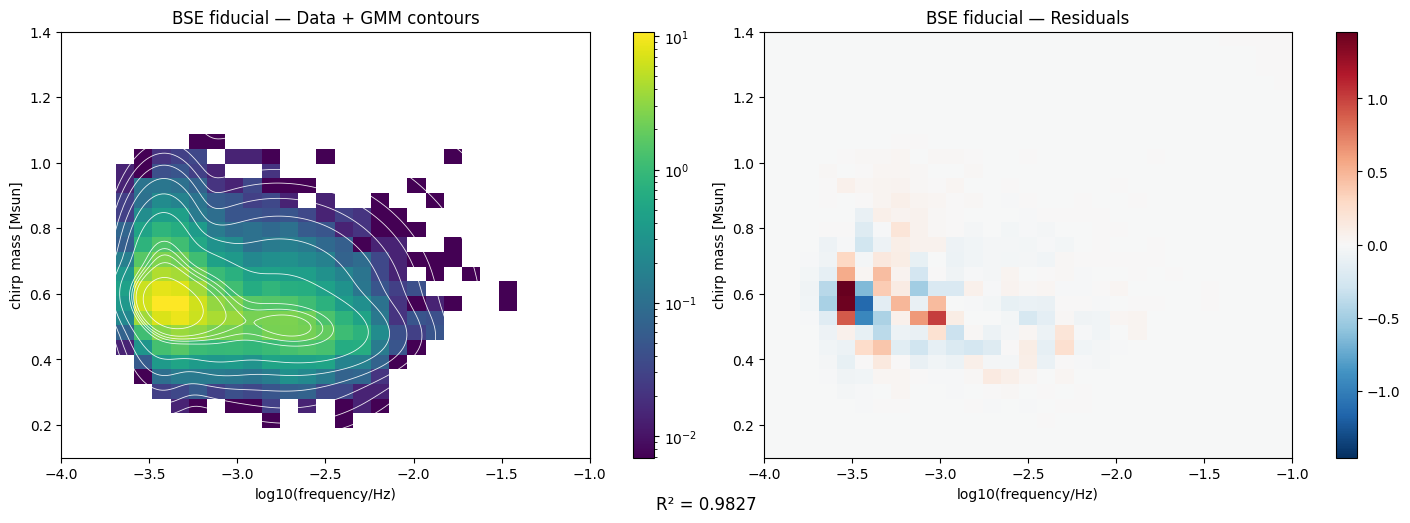

In [12]:
# Direct fit to combined
plot_gmm_comparison(combined, total_fit, title="Combined —")

# Summed individual GMMs vs combined
plot_gmm_comparison(combined, summed, title="Summed GMMs —")

# Summed individual GMMs with R^2>0.5 vs combined
plot_gmm_comparison(combined, summed_select, title="Summed GMMs (R²>0.5) —")

# Single simulation
r = fit_gmm(sims[18])
plot_gmm_comparison(sims[18]["heatmap"], r, title="BSE fiducial —")

# Final Result - GMM fit to combined data from 102 population models

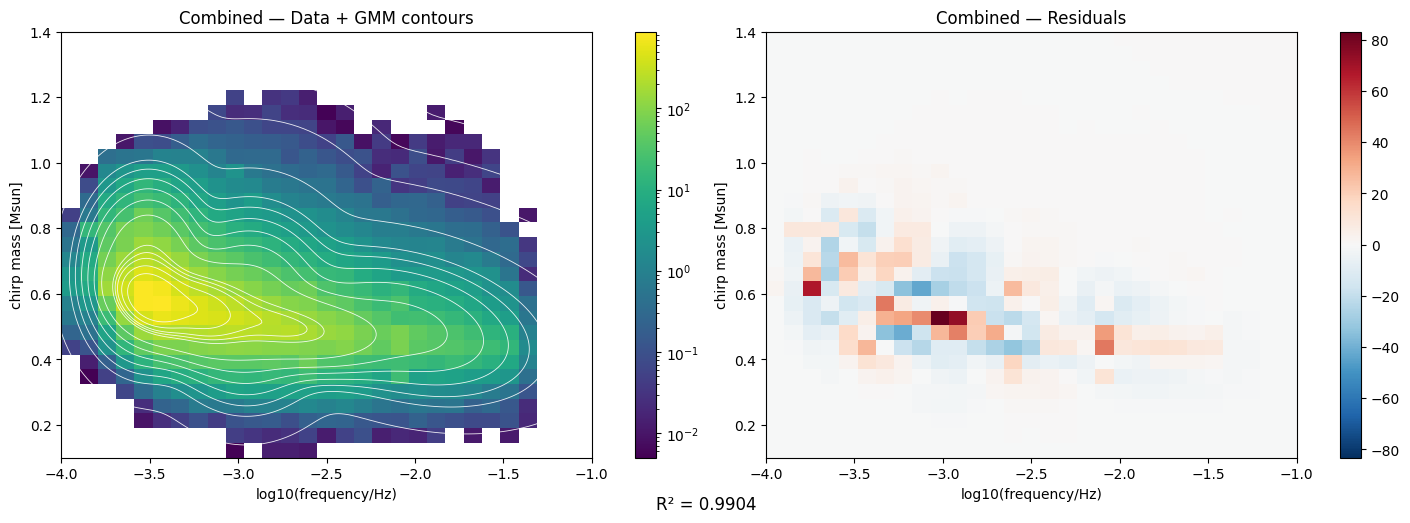

In [13]:
plot_gmm_comparison(combined, total_fit, title="Combined —")
#print_gmm_params(total_fit)

# Printing the prior

In [14]:
combined_fit_func = GMM_combined_fit(total_fit, printLaTeX=False) # True to print in LaTeX notation

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Coding the prior 

In [15]:
def combined_fit_func(f, Mc):
    """6-component GMM fit to combined heatmap. R² = 0.9904."""
    weights = [0.2294, 0.1444, 0.2534, 0.0620, 0.1833, 0.1275]
    means = [
        [-3.4941, 0.5846],
        [-2.6715, 0.4930],
        [-3.2362, 0.5526],
        [-2.0510, 0.4993],
        [-3.5154, 0.6689],
        [-2.9433, 0.5609],
    ]
    covs = [
        [[0.010790, -0.001486], [-0.001486, 0.002662]],
        [[0.057879, -0.003847], [-0.003847, 0.003256]],
        [[0.025530, -0.002133], [-0.002133, 0.004554]],
        [[0.101730, -0.009939], [-0.009939, 0.009511]],
        [[0.019447,  0.000336], [ 0.000336, 0.011663]],
        [[0.035272,  0.000360], [ 0.000360, 0.013418]],
    ]
    pt = np.atleast_2d(np.column_stack([np.ravel(f), np.ravel(Mc)]))
    result = np.zeros(len(pt))
    for w, mu, cov in zip(weights, means, covs):
        result += w * multivariate_normal.pdf(pt, mean=mu, cov=cov)
    return result.reshape(np.shape(f))

# Checking the coded prior

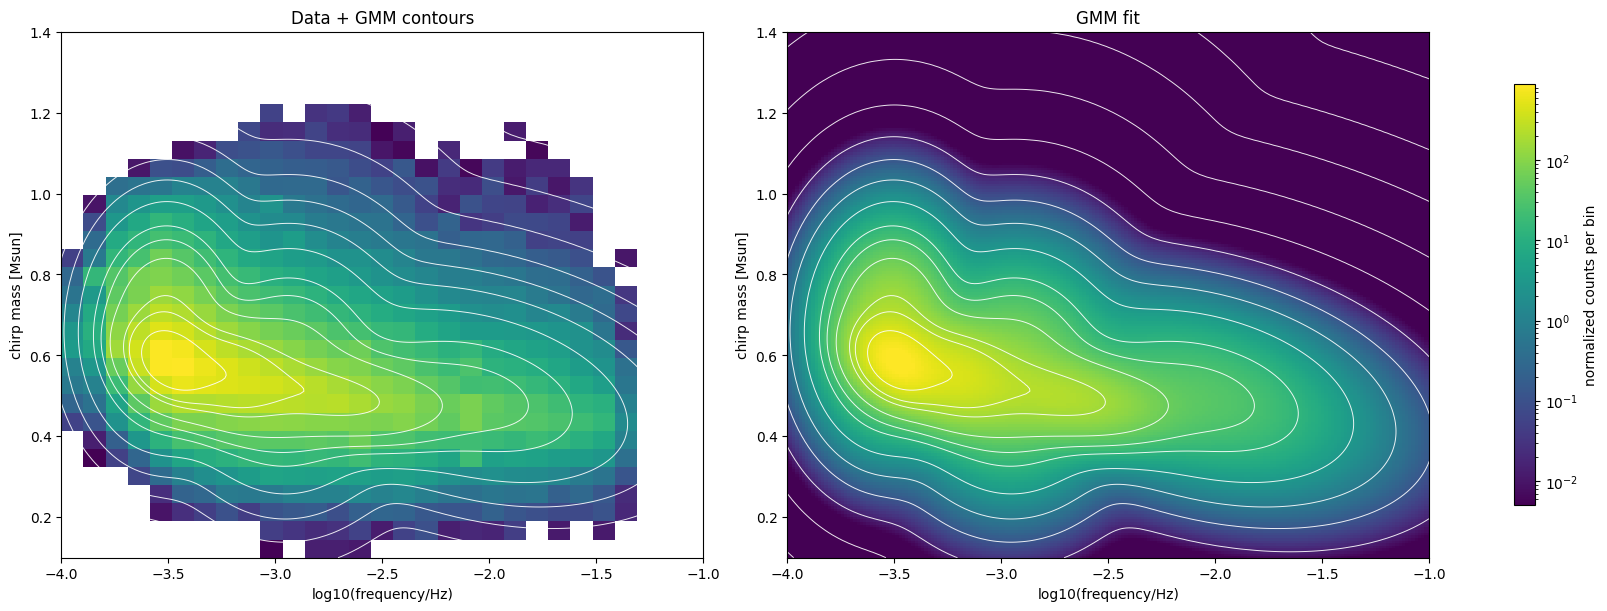

R² = 0.9905


In [16]:
r2 = prior_sanity_check(combined_fit_func, combined)